# Textual Inversion: Identity in the Text Embedding Space

This notebook is the second experiment in the Stable Diffusion personalization study.

Textual Inversion is the lightest trainable approach in the comparison: I keep the diffusion model fixed and learn only a small set of embedding vectors associated with a new token.

I compare the base-model generation with the learned token, then test the same identity representation together with OpenPose ControlNet.


## 1. Training the Identity Embedding


In [1]:
!curl -O https://raw.githubusercontent.com/huggingface/diffusers/v0.29.2/examples/textual_inversion/textual_inversion.py


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 40550  100 40550    0     0   107k      0 --:--:-- --:--:-- --:--:--  107k


I train the placeholder token `jortega` on the same identity dataset used throughout the project. The training script learns five embedding vectors while leaving the Stable Diffusion weights unchanged.


In [3]:
%%bash
python3 ./textual_inversion.py \
--num_vectors=5 \
--pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
--train_data_dir=./jortega \
--placeholder_token="jortega" \
--initializer_token="woman" \
--learnable_property="object" \
--repeats=100 \
--output_dir=./sd15_runwayml_jortega \
--seed=42 \
--resolution=512 \
--train_batch_size=1 \
--dataloader_num_workers=2 \
--max_train_steps=10000 \
--gradient_accumulation_steps=1 \
--learning_rate=5e-4 \
--lr_scheduler=constant \
--mixed_precision=fp16 \
--checkpointing_steps=1000

/home/jovyan/.local/lib/python3.12/site-packages/accelerate/accelerator.py:529: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
09/05/2026 14:12:49 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

{'variance_type', 'sample_max_value', 'dynamic_thresholding_ratio', 'prediction_type', 'clip_sample_range', 'rescale_betas_zero_snr', 'thresholding', 'timestep_spacing'} was not found in config. Values will be initialized to default values.
{'latents_std', 'use_quant_conv', 'shift_factor', 'force_upcast', 'mid_block_add_attention', 'use_post_quant_conv', 'scaling_factor', 'latents_mean'} was not found in config. Values will be initialized to default values.
All model checkpoint weights were used when initializing Autoenc

## 2. Baseline and Personalized Generation

I first generate from the base checkpoint without loading the learned embedding. I then load the Textual Inversion weights and repeat the portrait generation with the learned token.


In [4]:
import torch
import requests
from io import BytesIO

import cv2
import numpy as np
from PIL import Image
from IPython.display import display

from controlnet_aux import OpenposeDetector
from diffusers import AutoencoderKL, ControlNetModel, EulerAncestralDiscreteScheduler
from diffusers import StableDiffusionPipeline, StableDiffusionControlNetPipeline

/home/jovyan/.local/lib/python3.12/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/home/jovyan/.local/lib/python3.12/site-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/home/jovyan/.local/lib/python3.12/site-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_11m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_11m_224. This is because the name being registered conflicts with an existing name. Please che

In [5]:
device = torch.device("cuda")
dtype = torch.bfloat16


In [6]:
pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V5.1_noVAE",
    vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=dtype, use_safetensors=True),
    torch_dtype=dtype,
    safety_checker=None,
    use_safetensors=True).to(device, dtype)

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

In [7]:
pipe_scheduler_config = pipe.scheduler.config
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe_scheduler_config)

### Base model

  0%|          | 0/30 [00:00<?, ?it/s]

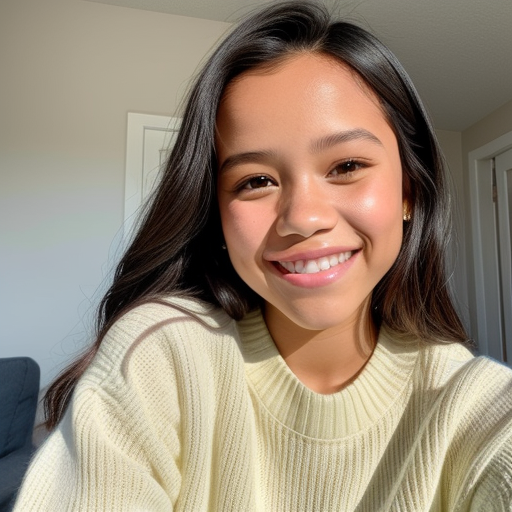

In [8]:
img = pipe(
    prompt="instagram photo, closeup face photo of jenna ortega in black sweater, pale skin, smile, hard shadows",
    negative_prompt="nsfw, naked, nude, deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime, mutated hands and fingers, deformed, distorted, disfigured, poorly drawn, bad anatomy, wrong anatomy, extra limb, missing limb, floating limbs, disconnected limbs, mutation, mutated, ugly, disgusting, amputation",
    height=512, width=512,
    num_inference_steps=30,
    guidance_scale=7.0,
    generator=torch.Generator(device=device).manual_seed(1),
).images[0]

img

### Learned identity token


In [9]:
pipe.load_textual_inversion("./sd15_runwayml_jortega/learned_embeds.safetensors")

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


  0%|          | 0/30 [00:00<?, ?it/s]

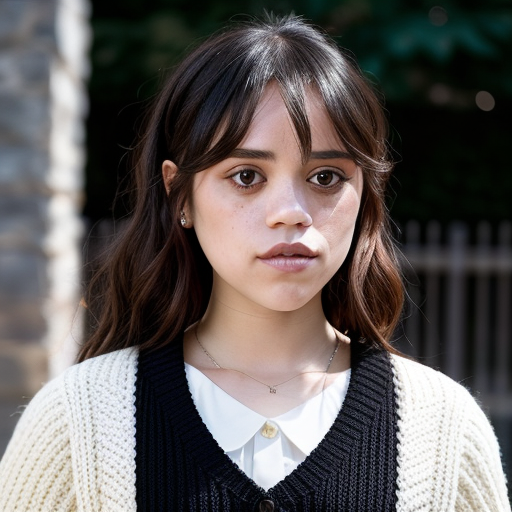

In [10]:
img = pipe(
    prompt="instagram photo, closeup face photo of jortega in black sweater, pale skin, smile, hard shadows",
    negative_prompt="nsfw, naked, nude, deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime, mutated hands and fingers, deformed, distorted, disfigured, poorly drawn, bad anatomy, wrong anatomy, extra limb, missing limb, floating limbs, disconnected limbs, mutation, mutated, ugly, disgusting, amputation",
    height=512, width=512,
    num_inference_steps=30,
    guidance_scale=7.0,
    generator=torch.Generator(device=device).manual_seed(1),
).images[0]

img


### Observation

The learned token improves identity specificity compared with relying on the base checkpoint alone. At the same time, the representation is limited to the text-embedding space, so fine identity details remain less stable than with stronger personalization methods.


## 3. Pose-Controlled Generation

I combine the learned identity token with the same OpenPose-style conditioning setup. This tests whether the compact embedding remains useful when the model must also follow an external pose.


In [11]:
pose_detector = OpenposeDetector.from_pretrained("lllyasviel/ControlNet")

/home/jovyan/.local/lib/python3.12/site-packages/controlnet_aux/open_pose/body.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = util.transfer(self.model, to

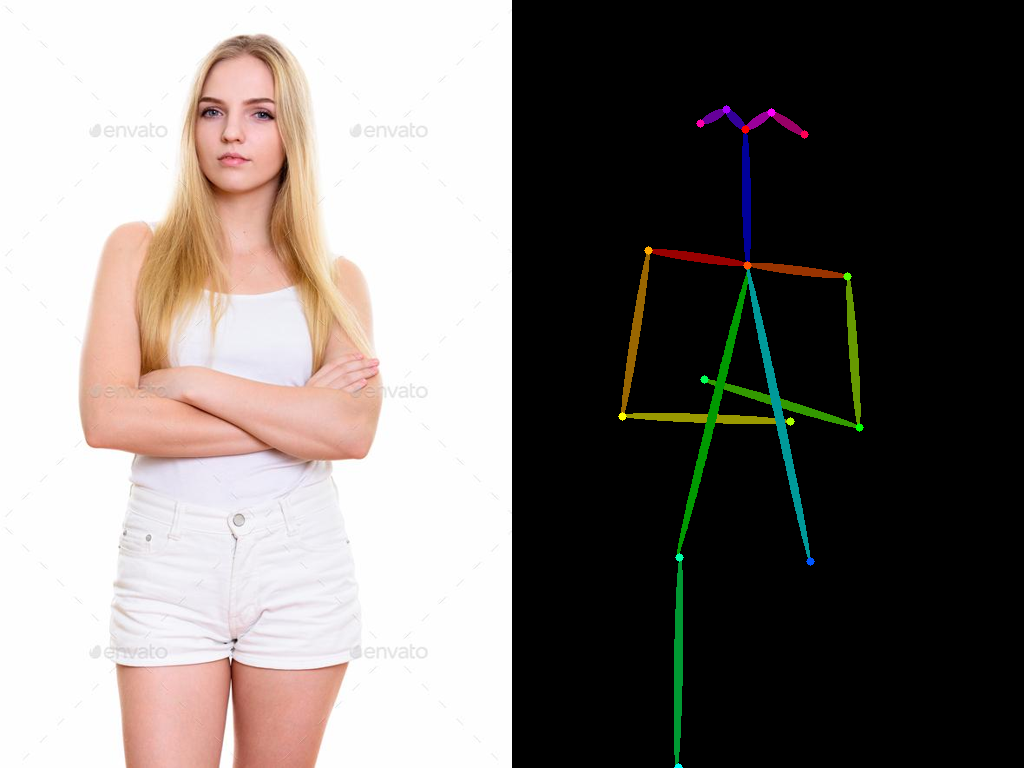

In [12]:
url = "https://s3.envato.com/files/287416893/23rdJanuary2017-4.jpg"
response = requests.get(url)
Image.open(BytesIO(response.content)).save("photo.jpg")

pose = pose_detector(Image.open("photo.jpg"))

Image.fromarray(np.hstack((
    np.asarray(Image.open("photo.jpg").resize((pose.width, pose.height))),
    np.asarray(pose),
)))


In [13]:
controlnet_pose = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-openpose", torch_dtype=torch.float16).to(device)

In [14]:
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V5.1_noVAE",
    controlnet=controlnet_pose,
    vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=dtype, use_safetensors=True),
    torch_dtype=dtype,
    safety_checker=None,
    use_safetensors=True
).to(device, dtype)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

In [15]:
pipe_scheduler_config = pipe.scheduler.config
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe_scheduler_config)
pipe.load_textual_inversion("./sd15_runwayml_jortega/learned_embeds.safetensors")

  0%|          | 0/50 [00:00<?, ?it/s]

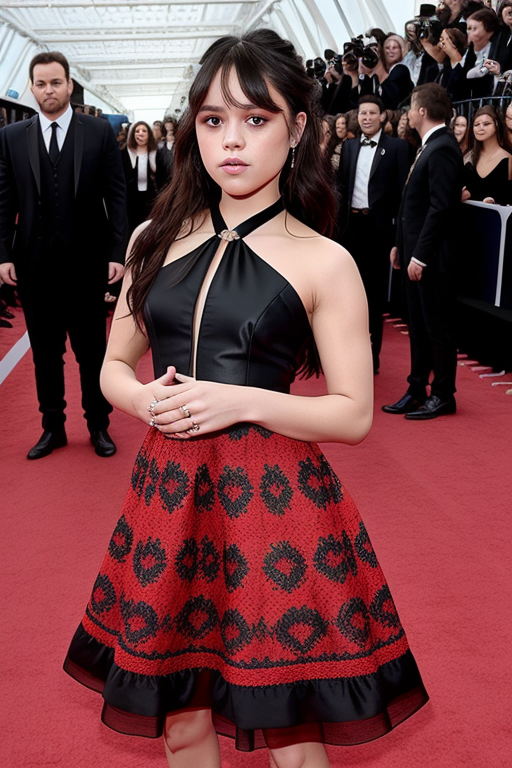

In [16]:
img = pipe(
    prompt="instagram photo, photo of jortega in a beautiful dress on a red carpet",
    negative_prompt="nsfw, naked, nude, deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime, mutated hands and fingers, deformed, distorted, disfigured, poorly drawn, bad anatomy, wrong anatomy, extra limb, missing limb, floating limbs, disconnected limbs, mutation, mutated, ugly, disgusting, amputation",
    guidance_scale=7,
    height=pose.height, width=pose.width,
    num_inference_steps=50,
    generator=torch.Generator(device=device).manual_seed(1),
    image=pose,
    controlnet_conditioning_scale=0.3,).images[0]

img

### Observation

The identity remains partially recognizable, but the pose-controlled result introduces more facial and background artifacts. In this experiment, Textual Inversion is effective as a very lightweight personalization method, but it is less robust when combined with stronger structural conditioning.
